# Atari Return Prediction: Adam vs UPGD Sweep Analysis (Rescaled Returns)

Same analysis as `sweep_comparison.ipynb` but for v2 experiments where returns are rescaled per-game by dividing by each game's return std. This equalizes each game's contribution to the MSE loss.

In [2]:
# Data collection command:
# from phd.research_utils.scripts.comet_download import run as comet_download
# comet_download(project="atari-prediction", n_threads=8, output_dir="data/")

In [3]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.research_utils.analysis.analysis_utils import *
from phd.research_utils.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [4]:
save_path = 'figures/'
config_data_path = 'data/atari-prediction_params.csv'
run_data_path = 'data/atari-prediction_metrics.csv'

# The metrics CSV uses 'update_step' instead of 'step'. Rename before loading.
run_df_raw = pd.read_csv(run_data_path, index_col=0)
if 'update_step' in run_df_raw.columns:
    run_df_raw = run_df_raw.rename(columns={'update_step': 'step'})
    run_df_raw.to_csv(run_data_path)

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)

# Show sweep names and run counts
{k: len(v) for k, v in config_dfs.items()}

{'adam_sweep_v2': 20,
 'upgd_sweep_v2': 600,
 'adam_sweep_v2_rescaled': 14,
 'upgd_sweep_v2_rescaled': 1056}

## Data Exploration

Check for data quality issues before plotting.

In [5]:
# Focus on v2 rescaled sweeps only
target_sweeps = ['adam_sweep_v2_rescaled', 'upgd_sweep_v2_rescaled']
config_dfs = {k: v for k, v in config_dfs.items() if k in target_sweeps}
run_dfs = {k: v for k, v in run_dfs.items() if k in target_sweeps}

for name in target_sweeps:
    cfg = config_dfs[name]
    runs = run_dfs[name]
    print(f"\n=== {name} ===")
    print(f"  Configs (completed runs): {len(cfg)}")
    print(f"  Metric rows: {len(runs)}")
    print(f"  Unique run_ids in metrics: {runs['run_id'].nunique()}")
    print(f"  Step range: {runs['step'].min()} - {runs['step'].max()}")
    print(f"  Inferred sweep vars: {infer_sweep_vars(cfg)}")
    print(f"  reinit values: {cfg['train|reinit_at_game_boundary'].value_counts().to_dict()}")


=== adam_sweep_v2_rescaled ===
  Configs (completed runs): 14
  Metric rows: 9100
  Unique run_ids in metrics: 14
  Step range: 4000.0 - 2600000.0
  Inferred sweep vars: ['optimizer|learning_rate', 'train|reinit_at_game_boundary']
  reinit values: {False: 7, True: 7}

=== upgd_sweep_v2_rescaled ===
  Configs (completed runs): 1056
  Metric rows: 686400
  Unique run_ids in metrics: 1056
  Step range: 4000.0 - 2600000.0
  Inferred sweep vars: ['optimizer|beta_utility', 'optimizer|learning_rate', 'optimizer|sigma', 'optimizer|weight_decay', 'train|reinit_at_game_boundary']
  reinit values: {False: 528, True: 528}


In [6]:
# Check for NaN in the loss column — NaN means the model diverged (Comet silently drops NaN values)
for name in target_sweeps:
    runs = run_dfs[name]
    n_runs = runs['run_id'].nunique()
    loss_per_run = runs.groupby('run_id')['loss'].apply(lambda x: x.notna().sum())
    n_all_nan = (loss_per_run == 0).sum()
    n_partial = ((loss_per_run > 0) & (loss_per_run < loss_per_run.max())).sum()
    n_complete = (loss_per_run == loss_per_run.max()).sum()

    print(f"\n=== {name}: {n_runs} completed runs ===")
    print(f"  Full loss data:    {n_complete} runs ({loss_per_run.max()} rows each)")
    print(f"  Partial (mid-run divergence): {n_partial} runs")
    print(f"  All NaN (immediate divergence): {n_all_nan} runs")

    if n_all_nan > 0 or n_partial > 0:
        cfg = config_dfs[name]
        sweep_vars = infer_sweep_vars(cfg)
        diverged_ids = loss_per_run[loss_per_run == 0].index
        partial_ids = loss_per_run[(loss_per_run > 0) & (loss_per_run < loss_per_run.max())].index
        complete_ids = loss_per_run[loss_per_run == loss_per_run.max()].index

        print(f"\n  WARNING: {n_all_nan + n_partial}/{n_runs} runs diverged (produced NaN loss).")
        print(f"  These runs are still in the data — downstream plots may show gaps or be affected.")

        for var in sweep_vars:
            vals_complete = set(cfg[cfg['run_id'].isin(complete_ids)][var].unique())
            vals_all = set(cfg[var].unique())
            vals_diverged_only = vals_all - vals_complete
            if vals_diverged_only:
                print(f"  {var}: values {vals_diverged_only} have NO non-divergent runs")


=== adam_sweep_v2_rescaled: 14 completed runs ===
  Full loss data:    14 runs (650 rows each)
  Partial (mid-run divergence): 0 runs
  All NaN (immediate divergence): 0 runs

=== upgd_sweep_v2_rescaled: 1056 completed runs ===
  Full loss data:    669 runs (650 rows each)
  Partial (mid-run divergence): 363 runs
  All NaN (immediate divergence): 24 runs

  These runs are still in the data — downstream plots may show gaps or be affected.


## Find Best Hyperparameters

Split by `train|reinit_at_game_boundary` to find separate best configs for reinit=True vs reinit=False.

In [7]:
sweep_split_vars = {
    'adam_sweep_v2_rescaled': ['train|reinit_at_game_boundary'],
    'upgd_sweep_v2_rescaled': ['train|reinit_at_game_boundary'],
}

best_config_dfs, best_run_dfs, best_hyperparam_vals = get_best_ablation_values(
    config_dfs, run_dfs,
    sweep_split_vars=sweep_split_vars,
    split_dfs_by_split_vars=True,
    metric_col='loss',
    metric_direction='min',
    metric_type='cumulative',
    step_col='step',
)

print("\n=== Keys ===")
print(list(best_hyperparam_vals.keys()))
for k, v in best_hyperparam_vals.items():
    print(f"\n{k}: {v}")
    print(f"  Runs: {len(best_config_dfs[k])}")


=== adam_sweep_v2_rescaled ===

Configuration: train|reinit_at_game_boundary=False | # runs: 1
  Best optimizer|learning_rate=2**-15

Configuration: train|reinit_at_game_boundary=True | # runs: 1
  Best optimizer|learning_rate=2**-15


=== upgd_sweep_v2_rescaled ===

Configuration: train|reinit_at_game_boundary=False | # runs: 1
  Best optimizer|learning_rate=2**-12
  Best optimizer|sigma=2**-1
  Best optimizer|beta_utility=0.99
  Best optimizer|weight_decay=0.01

Configuration: train|reinit_at_game_boundary=True | # runs: 1
  Best optimizer|learning_rate=2**-10
  Best optimizer|sigma=0.2
  Best optimizer|beta_utility=0.99
  Best optimizer|weight_decay=0.0


=== Keys ===
['adam_sweep_v2_rescaled&train|reinit_at_game_boundary=False', 'adam_sweep_v2_rescaled&train|reinit_at_game_boundary=True', 'upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=False', 'upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=True']

adam_sweep_v2_rescaled&train|reinit_at_game_boundary=False: {'optimizer

## 1. Main Comparison: Adam vs UPGD, Reinit vs No-Reinit

Learning curves for the best hyperparameter configuration of each condition.

In [8]:
algo_map = {}
for k in best_hyperparam_vals.keys():
    parts = k.split('&')
    sweep = parts[0].replace('_sweep_v2_rescaled', '').upper()
    reinit_val = 'Reinit' if 'True' in parts[1] else 'No Reinit'
    algo_map[k] = f'{sweep} ({reinit_val})'

print("Algorithm map:", algo_map)

combined_config_df = pd.concat(
    [df.assign(split_name=k) for k, df in best_config_dfs.items()]
)
combined_run_df = pd.concat(list(best_run_dfs.values()))

combined_config_df = combined_config_df[combined_config_df['split_name'].isin(algo_map.keys())].copy()
valid_run_ids = combined_config_df['run_id'].unique()
combined_run_df = combined_run_df[combined_run_df['run_id'].isin(valid_run_ids)].copy()
combined_config_df['algo'] = combined_config_df['split_name'].map(algo_map)

print(f"\nTotal runs: {len(combined_config_df)}")
print(combined_config_df['algo'].value_counts())

Algorithm map: {'adam_sweep_v2_rescaled&train|reinit_at_game_boundary=False': 'ADAM (No Reinit)', 'adam_sweep_v2_rescaled&train|reinit_at_game_boundary=True': 'ADAM (Reinit)', 'upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=False': 'UPGD (No Reinit)', 'upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=True': 'UPGD (Reinit)'}

Total runs: 4
algo
ADAM (No Reinit)    1
ADAM (Reinit)       1
UPGD (No Reinit)    1
UPGD (Reinit)       1
Name: count, dtype: int64


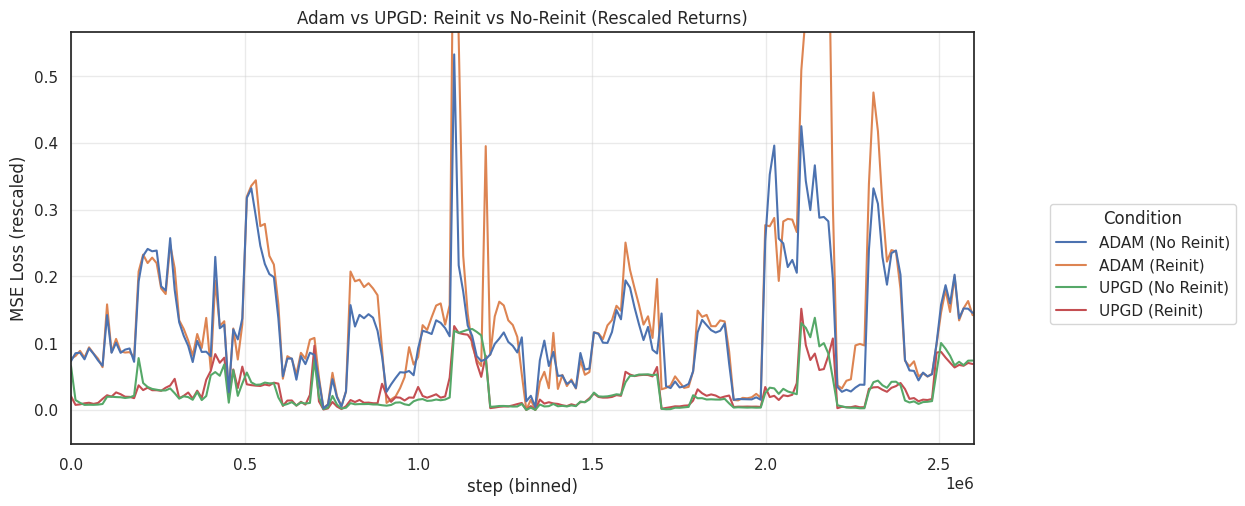

In [9]:
plot_learning_curves(
    run_df=combined_run_df,
    config_df=combined_config_df,
    n_bins=200,
    figsize=(10, 5),
    hue_col='algo',
    legend_title='Condition',
    show_ci=True,
)
plt.title('Adam vs UPGD: Reinit vs No-Reinit (Rescaled Returns)')
plt.ylabel('MSE Loss (rescaled)')
plt.show()

## 2. Learning Curves with Baseline Loss

Compare model loss against the running-mean baseline to contextualize prediction quality.

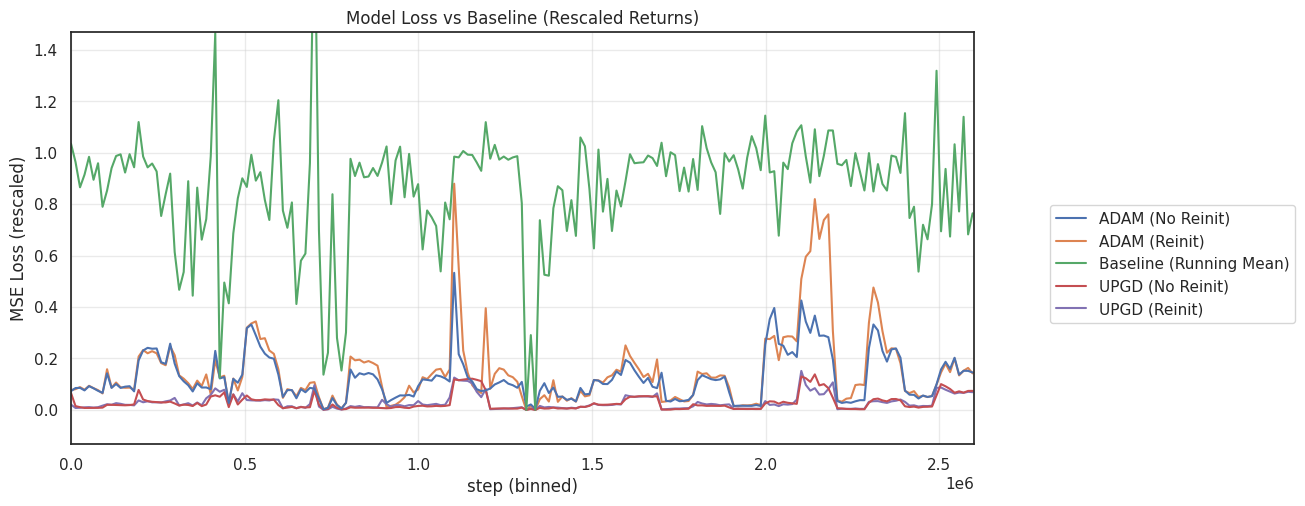

In [10]:
# Use a single baseline (from any condition — they share the same data stream)
first_key = list(best_run_dfs.keys())[0]
single_baseline = best_run_dfs[first_key][['run_id', 'step', 'baseline_loss']].copy()
single_baseline = single_baseline.rename(columns={'baseline_loss': 'loss'})
single_baseline['algo'] = 'Baseline (Running Mean)'

model_dfs = []
for k, run_df in best_run_dfs.items():
    rows = run_df[['run_id', 'step', 'loss']].copy()
    rows['algo'] = algo_map[k]
    model_dfs.append(rows)

plot_df = pd.concat([single_baseline] + model_dfs, ignore_index=True)

plot_learning_curves(
    run_df=plot_df,
    n_bins=200,
    figsize=(10, 5),
    hue_col='algo',
    legend_title='',
    show_ci=False,
)
plt.title('Model Loss vs Baseline (Rescaled Returns)')
plt.ylabel('MSE Loss (rescaled)')
plt.show()

## 3. Adam Learning Rate Sensitivity

Sensitivity to learning rate, with reinit as hue.

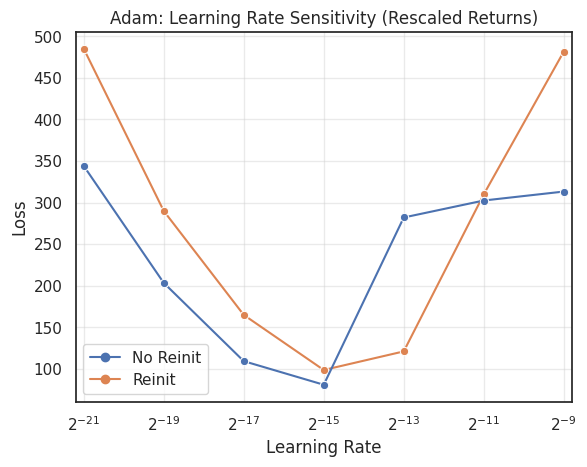

In [11]:
adam_config = config_dfs['adam_sweep_v2_rescaled'].copy()
adam_run = run_dfs['adam_sweep_v2_rescaled'].copy()

adam_config['Reinit'] = adam_config['train|reinit_at_game_boundary'].map({True: 'Reinit', False: 'No Reinit'})

plot_param_sensitivity(
    run_df=adam_run,
    config_df=adam_config,
    x_col='optimizer|learning_rate',
    title='Adam: Learning Rate Sensitivity (Rescaled Returns)',
    x_label='Learning Rate',
    y_label='Loss',
    metric_col='loss',
    metric_type='cumulative',
    step_col='step',
    hue_col='Reinit',
    legend_title='',
    pow_2_x_axis=True,
    show_ci=True,
)
plt.show()

## 4. UPGD Hyperparameter Sensitivity

One plot per hyperparameter (learning_rate, beta_utility, sigma, weight_decay), with reinit as hue. For each plot, all other hyperparameters are held at their best values (separately for reinit and no-reinit).

In [12]:
# Get best hyperparams for each reinit condition
upgd_keys = [k for k in best_hyperparam_vals if k.startswith('upgd_sweep_v2_rescaled')]
print("UPGD split keys:", upgd_keys)
for k in upgd_keys:
    print(f"  {k}: {best_hyperparam_vals[k]}")

upgd_config = config_dfs['upgd_sweep_v2_rescaled'].copy()
upgd_run = run_dfs['upgd_sweep_v2_rescaled'].copy()
upgd_config['Reinit'] = upgd_config['train|reinit_at_game_boundary'].map({True: 'Reinit', False: 'No Reinit'})

upgd_hyperparam_names = list(best_hyperparam_vals[upgd_keys[0]].keys())
print("\nHyperparams to plot:", upgd_hyperparam_names)

UPGD split keys: ['upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=False', 'upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=True']
  upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=False: {'optimizer|learning_rate': 0.000244140625, 'optimizer|sigma': 0.5, 'optimizer|beta_utility': 0.99, 'optimizer|weight_decay': 0.01}
  upgd_sweep_v2_rescaled&train|reinit_at_game_boundary=True: {'optimizer|learning_rate': 0.0009765625, 'optimizer|sigma': 0.2, 'optimizer|beta_utility': 0.99, 'optimizer|weight_decay': 0.0}

Hyperparams to plot: ['optimizer|learning_rate', 'optimizer|sigma', 'optimizer|beta_utility', 'optimizer|weight_decay']


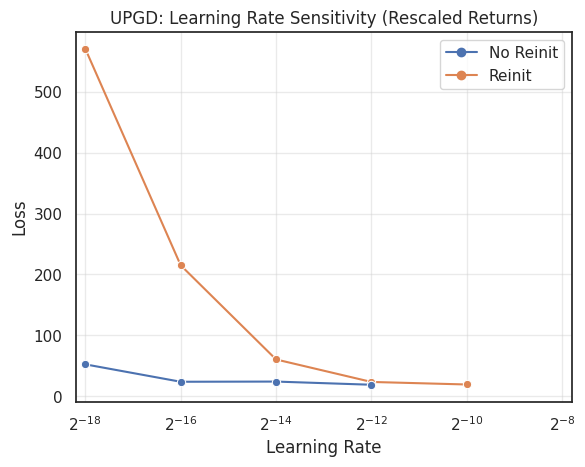

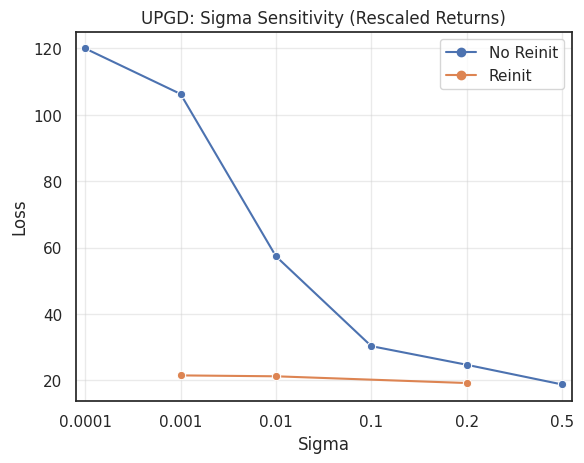

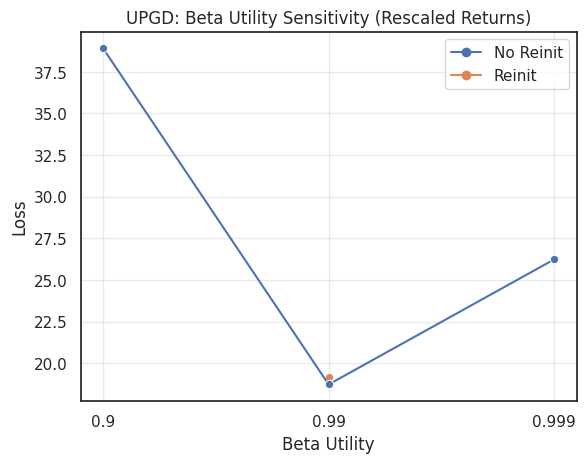

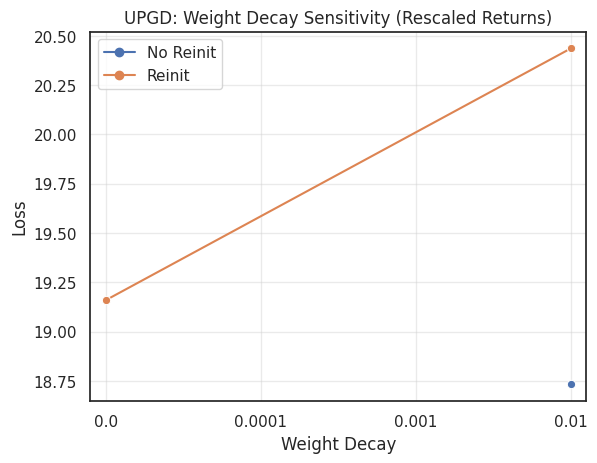

In [13]:
for param_name in upgd_hyperparam_names:
    dfs_to_plot = []
    for upgd_key in upgd_keys:
        best_vals = best_hyperparam_vals[upgd_key]
        reinit_val = True if 'True' in upgd_key else False

        hold_values = {k: v for k, v in best_vals.items() if k != param_name}
        hold_values['train|reinit_at_game_boundary'] = reinit_val

        sel_run, sel_config = select_experiment_runs(
            run_df=upgd_run,
            config_df=upgd_config,
            chosen_values=hold_values,
        )
        dfs_to_plot.append((sel_run, sel_config))

    plot_run = pd.concat([d[0] for d in dfs_to_plot], ignore_index=True)
    plot_config = pd.concat([d[1] for d in dfs_to_plot], ignore_index=True)

    param_label = param_name.split('|')[-1].replace('_', ' ').title()
    plot_param_sensitivity(
        run_df=plot_run,
        config_df=plot_config,
        x_col=param_name,
        title=f'UPGD: {param_label} Sensitivity (Rescaled Returns)',
        x_label=param_label,
        y_label='Loss',
        metric_col='loss',
        metric_type='cumulative',
        step_col='step',
        hue_col='Reinit',
        legend_title='',
        pow_2_x_axis='learning_rate' in param_name,
        show_ci=True,
    )
    plt.show()